In [1]:
# conda env: mmdeploy

In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [2]:
from datetime import datetime
from glob import glob
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from multicamera_airflow_pipeline.jonah_241112.skeletons.defaults import (
    conf_thresholds_by_camera,
    keypoint_info,
    kpt_dict,
)
from multicamera_labelling_and_training.labelling_set_to_training_set import get_image_size, Int32Encoder

/home/jop9552/miniconda3/envs/mmdeploy_JP_v2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# propagate any missing labels onto the training data
JP: in this particular round of fine-tuning, I just wanted to focus on the forepaws, so that's the only ROI I asked instalabel to do. So I need to go and get the pipeline's keypoint detections for every other bodypart and add them to the training data. Then hopefully we won't "perturb" the network's understanding of the other bodyparts.

### load data

In [3]:
instalabel_results_dir = "/n/groups/datta/6cam_keypoint_networks/training_data/20241216_JP_forepaws/instalabel_results"
airflow_results_dir = "/n/groups/datta/kpts_pipeline/jonah_241112/results/2D_predictions/"
labeled_kps = ["right_fore_paw", "left_fore_paw"]
unlabeled_kps = list(set(kpt_dict.keys()) - set(labeled_kps))

In [4]:
# read in the COCO labels. put into a dict with key as the image name and val as the keypoints as a (n keypoints x 2) array.
# nb in this set, frames are not matched across cameras.
with open(os.path.join(instalabel_results_dir, "annotations/coco_annotations.json"), "r") as f:
    coco_labels = json.load(f)
coco_labels.keys()

dict_keys(['images', 'annotations', 'categories'])

In [5]:
image_id_to_filename = {d["id"]: d["file_name"] for d in coco_labels["images"]}
category_id_to_kpt_name = {d["id"]: d["name"] for d in coco_labels["categories"]}
img_file_metainfo = {}

In [6]:
coco_labels["annotations"][0].keys()

dict_keys(['id', 'image_id', 'category_id', 'segmentation', 'area', 'bbox', 'iscrowd', 'attributes'])

In [7]:
annos = {}
for anno in coco_labels["annotations"]:
    img_id = anno["image_id"]
    img_file = image_id_to_filename[img_id]
    img_file_metainfo[img_file] = {
        "id": img_id, 
        "session": img_file.split(".")[0], 
        "camera": img_file.split(".")[1],
        "frame": int(img_file.split(".")[2].split("_")[-1]),
    }
    assert img_file_metainfo[img_file]["camera"] in ["top", "bottom", "side1", "side2", "side3", "side4"]
    if img_file not in annos:
        kpts_2d = annos[img_file] = np.zeros((len(keypoint_info), 3)).astype(int)  # x, y, visibility flag ("v=0: not labeled (in which case x=y=0), v=1: labeled but not visible, and v=2: labeled and visible.")
    else:
        kpts_2d = annos[img_file]

    # Figure out index of keypoint in the 2d pred data
    kpt_name = category_id_to_kpt_name[anno["category_id"]]
    kpt_idx = kpt_dict[kpt_name]

    # Get the centroid of the instalabel segmentation
    seg = anno["segmentation"]
    seg = np.array(seg).reshape(-1, 2)
    centroid = np.round(np.mean(seg, axis=0)).astype(int)
    
    # Set the keypoint
    kpts_2d[kpt_idx, :2] = centroid
    kpts_2d[kpt_idx, 2] = 2  # visible


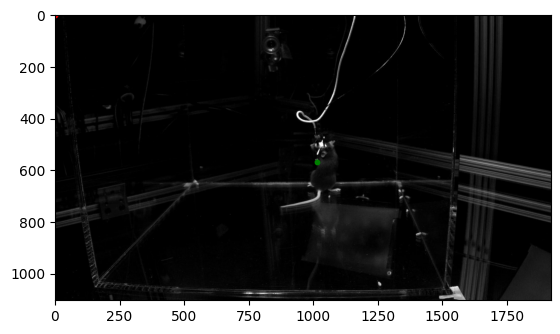

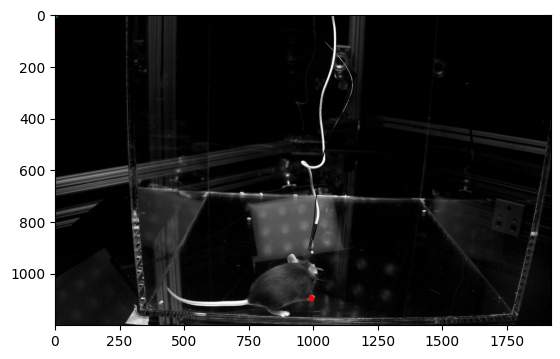

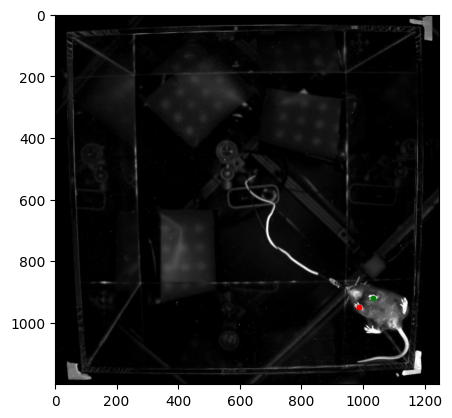

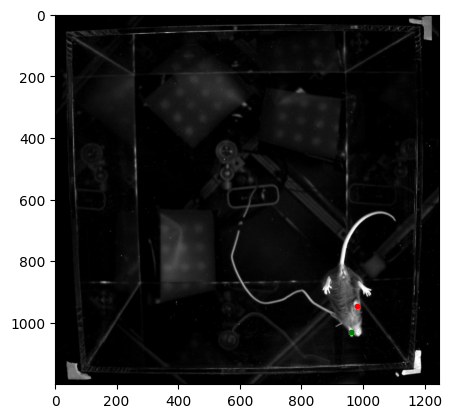

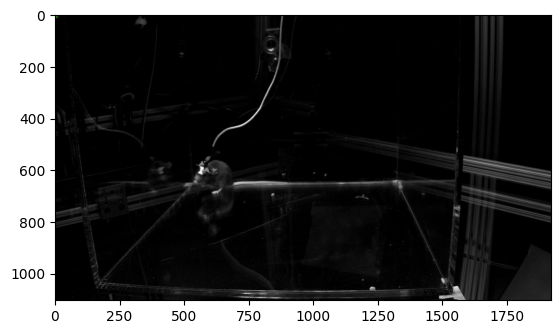

In [8]:
# Check a few random images
for img_file in np.random.choice(list(annos.keys()), 5):
    img = plt.imread(os.path.join(instalabel_results_dir, "images", img_file + ".jpg"))
    plt.figure()
    plt.imshow(img)
    kpts_2d = annos[img_file]
    plt.scatter(kpts_2d[kpt_dict["right_fore_paw"], 0], kpts_2d[kpt_dict["right_fore_paw"], 1], s=10, c="r")
    plt.scatter(kpts_2d[kpt_dict["left_fore_paw"], 0], kpts_2d[kpt_dict["left_fore_paw"], 1], s=10, c="g")
    

In [9]:
# fill in the rest of the keypoints with the airflow pipeline results
sessions = np.unique([img_file_metainfo[img_file]["session"] for img_file in annos.keys()])
cameras = ["top", "bottom", "side1", "side2", "side3", "side4"]
for session in sessions:
    for cam in cameras:
        
        # Find images to use
        imgs_to_update = [img_file for img_file in annos.keys() if img_file_metainfo[img_file]["session"] == session and img_file_metainfo[img_file]["camera"] == cam]
        if len(imgs_to_update) == 0:
            continue

        # Get conf thresholds for this camera
        cam_type = "side" if "side" in cam else cam
        conf_thresholds = conf_thresholds_by_camera[cam_type]

        # Get the 2d preds from airflow
        preds_2d_file = list(glob(os.path.join(airflow_results_dir, session, f"{session}.{cam}*.h5")))
        if len(preds_2d_file) == 0:
            print(f"No 2d preds found for {session} {cam} camera")
            continue
        elif len(preds_2d_file) > 1:
            print(f"Multiple 2d preds found for {session} {cam} camera")
            continue
        preds_2d_file = preds_2d_file[0]
        with h5py.File(preds_2d_file, "r") as f:
            preds_2d = np.array(f["keypoint_coords"]).squeeze()
            confs = np.array(f["keypoint_conf"]).squeeze()
        
        # Update the keypoints
        for img_file in imgs_to_update:
            for kpt_name in unlabeled_kps:
                kpt_idx = kpt_dict[kpt_name]
                frame_num = img_file_metainfo[img_file]["frame"]

                # Check if nn confidence is above threshold, if not dont do anything
                confidence = confs[frame_num, kpt_idx]
                this_thresh = [val for keypoint_type,val in conf_thresholds.items() if keypoint_type in kpt_name]
                assert len(this_thresh) == 1, f"Expected 1 threshold, got {len(this_thresh)}"
                this_thresh = this_thresh[0]
                if confidence < this_thresh:
                    continue
                
                # Update the keypoint
                annos[img_file][kpt_idx, :2] = preds_2d[frame_num, kpt_idx, :]
                annos[img_file][kpt_idx, 2] = 2  # 2 means labeled and visible



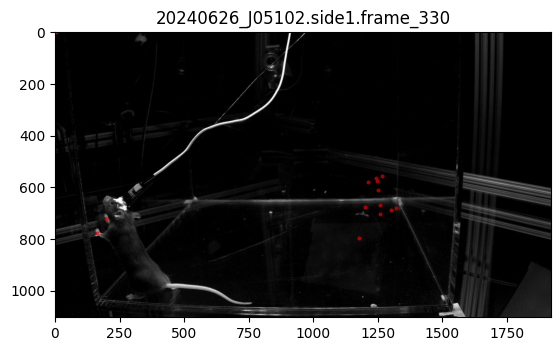

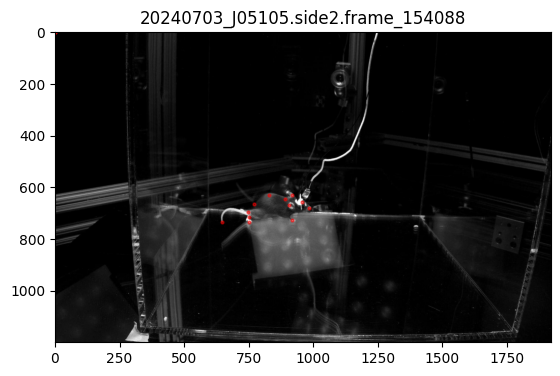

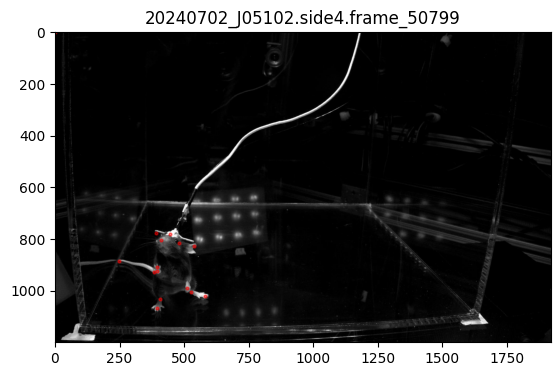

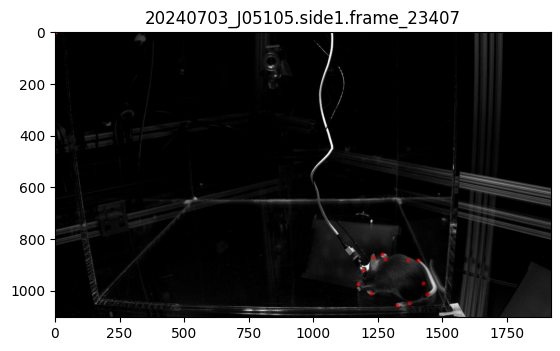

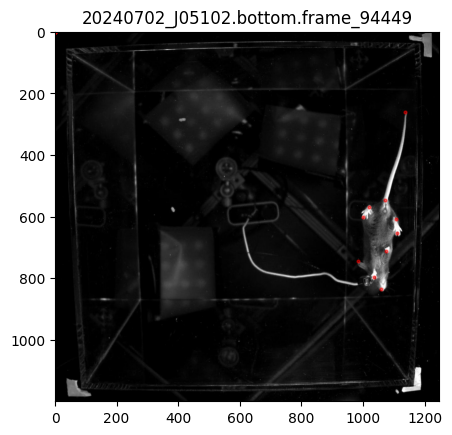

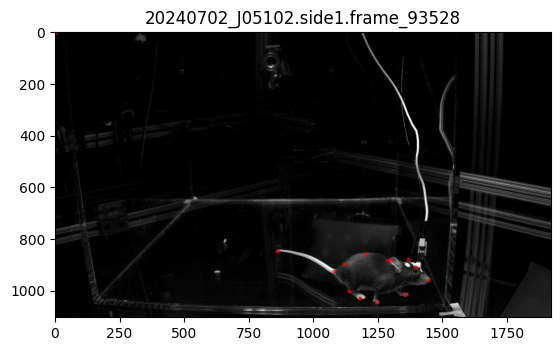

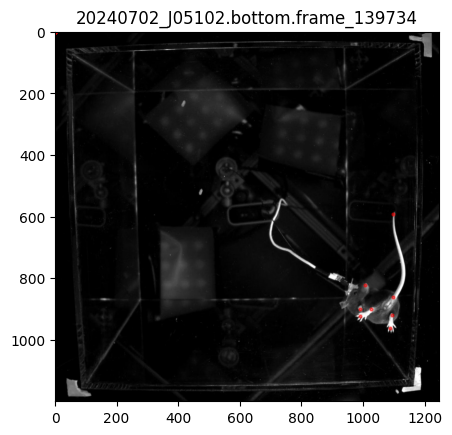

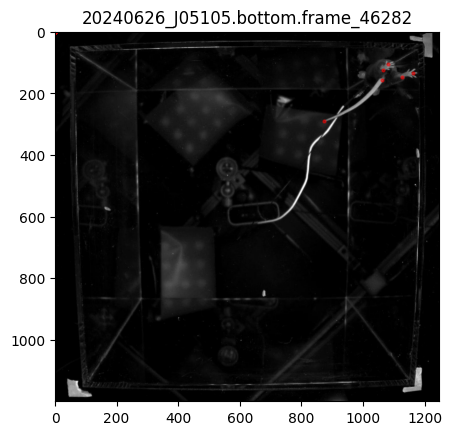

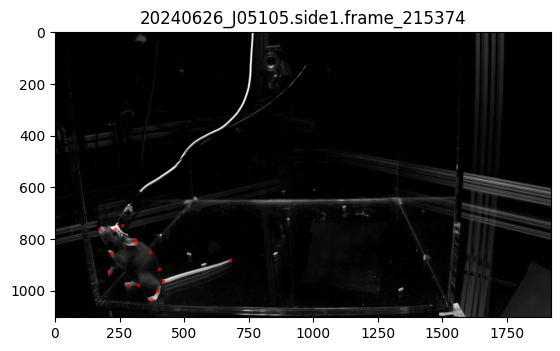

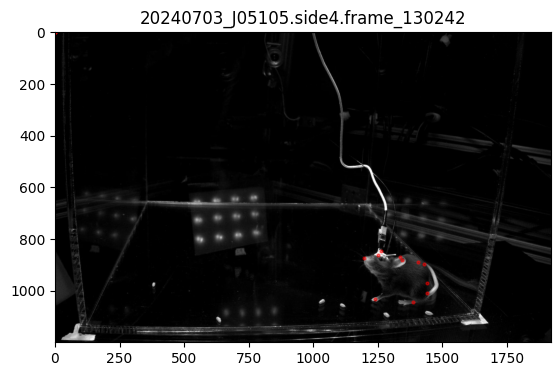

In [11]:
# Check a few random images
for img_file in np.random.choice(list(annos.keys()), 10, replace=False):
    img = plt.imread(os.path.join(instalabel_results_dir, "images", img_file + ".jpg"))
    plt.figure()
    plt.imshow(img)
    kpts_2d = annos[img_file]
    for kpt_name in labeled_kps + unlabeled_kps:
        plt.scatter(kpts_2d[kpt_dict[kpt_name], 0], kpts_2d[kpt_dict[kpt_name], 1], s=4, c="r", alpha=0.5)
    plt.title(img_file)
    

### clean the data

In [12]:
# # make sure centroid of unlabeled keypoints (ie detections from airflow) are close by to the labeled keypoints
# # do this by visualizing the images where the distance between the centroids is large and just manually picking out the bad ones
# dists = np.zeros(len(annos))
# ii = 0
# for iAnno, (img_name, kpts_2d) in enumerate(annos.items()):
#     img_file = Path(os.path.join(instalabel_results_dir, "images", img_name + ".jpg"))
#     frame_num = img_file_metainfo[img_name]["frame"]

#     unlabeled_kp_idxs = [kpt_dict[kpt_name] for kpt_name in unlabeled_kps]
#     labeled_kp_idxs = [kpt_dict[kpt_name] for kpt_name in labeled_kps]
    
#     detections = kpts_2d[unlabeled_kp_idxs]
#     detected_centroid = np.mean(detections[detections[:,2]==2, :2], axis=0)
    
#     labels = kpts_2d[labeled_kp_idxs]
#     labeled_centroid = np.mean(labels[labels[:,2]==2, :2], axis=0)
#     dist = np.linalg.norm(detected_centroid - labeled_centroid)
#     dists[iAnno] = dist

#     if dist > 175:
#         img = plt.imread(img_file)
#         plt.figure()
#         plt.imshow(img)
#         plt.scatter(kpts_2d[kpt_dict["right_fore_paw"], 0], kpts_2d[kpt_dict["right_fore_paw"], 1], s=10, c="r")
#         plt.scatter(kpts_2d[kpt_dict["left_fore_paw"], 0], kpts_2d[kpt_dict["left_fore_paw"], 1], s=10, c="g")
#         plt.scatter(detected_centroid[0], detected_centroid[1], s=10, c="b")
#         for kpt_name in unlabeled_kps:
#             plt.scatter(kpts_2d[kpt_dict[kpt_name], 0], kpts_2d[kpt_dict[kpt_name], 1], s=4, c="w", alpha=0.5)
#         plt.title(img_file)
#         ii += 1
#         print(img_file)


In [13]:
# plt.hist(dists)

In [10]:
# Remove weird data from 20240626_J05102.side1 first few minutes
to_remove = []
for iAnno, (img_name, kpts_2d) in enumerate(annos.items()):
    img_file = Path(os.path.join(instalabel_results_dir, "images", img_name + ".jpg"))
    frame_num = img_file_metainfo[img_name]["frame"]

    if "side1" in img_name and "20240626_J05102" in img_name and frame_num < 10000:
        to_remove.append(img_name)

for img_name in to_remove:
    del annos[img_name]

In [11]:
to_remove = [
    "/n/groups/datta/6cam_keypoint_networks/training_data/20241216_JP_forepaws/instalabel_results/images/20240626_J05105.side3.frame_171497.jpg",
    "/n/groups/datta/6cam_keypoint_networks/training_data/20241216_JP_forepaws/instalabel_results/images/20240626_J05105.side4.frame_83007.jpg",
    "/n/groups/datta/6cam_keypoint_networks/training_data/20241216_JP_forepaws/instalabel_results/images/20240703_J05105.side3.frame_67024.jpg",
    "/n/groups/datta/6cam_keypoint_networks/training_data/20241216_JP_forepaws/instalabel_results/images/20240703_J05105.side3.frame_167187.jpg"
]
for img_file in to_remove:
    img_name = Path(img_file).stem
    del annos[img_name]

### export back to coco

In [12]:
# initialize a coco dataset dict
output_dir = Path("/n/groups/datta/6cam_keypoint_networks/training_data/20241216_JP_forepaws/COCO_format")
keypoints_to_ignore = []
keypoints_order = list(kpt_dict.keys())

# create dataset folders
Path(output_dir).mkdir(parents=True, exist_ok=True)
Path(output_dir / "annotations").mkdir(parents=True, exist_ok=True)
# Path(output_dir / "train").mkdir(parents=True, exist_ok=True)
# Path(output_dir / "val").mkdir(parents=True, exist_ok=True)

# this will be populated with all data, then later split into train and validation
dataset_dict = {}
dataset_dict["info"] = {
    "contributor": "",
    "date_created": datetime.today().strftime("%Y-%m-%d"),
    "description": "",
    "url": "",
    "versoin": "1.0",
    "year": datetime.now().year,
}

dataset_dict["categories"] = [
    {
        "id": 0,
        "name": "Mouse",
        "num_keypoints": len(kpt_dict),
        "supercategory": "None",
    }
]
dataset_dict["licenses"] = [{"id": 1, "name": "", "url": ""}]
dataset_dict["annotations"] = []
dataset_dict["images"] = []
n_keypoints = len(kpt_dict)

dataset_dict["skeleton"] = [{"keypointA": "tail_tip", "keypointB": "tail_base", "length": 0, "name": "Joint 1"}, {"keypointA": "tail_base", "keypointB": "spine_low", "length": 0, "name": "Joint 2"}, {"keypointA": "spine_low", "keypointB": "spine_mid", "length": 0, "name": "Joint 3"}, {"keypointA": "spine_mid", "keypointB": "spine_high", "length": 0, "name": "Joint 4"}, {"keypointA": "spine_high", "keypointB": "left_ear", "length": 0, "name": "Joint 5"}, {"keypointA": "spine_high", "keypointB": "right_ear", "length": 0, "name": "Joint 6"}, {"keypointA": "spine_high", "keypointB": "forehead", "length": 0, "name": "Joint 7"}, {"keypointA": "forehead", "keypointB": "nose_tip", "length": 0, "name": "Joint 8"}, {"keypointA": "left_hind_paw_back", "keypointB": "left_hind_paw_front", "length": 0, "name": "Joint 9"}, {"keypointA": "spine_low", "keypointB": "left_hind_paw_back", "length": 0, "name": "Joint 10"}, {"keypointA": "right_hind_paw_back", "keypointB": "right_hind_paw_front", "length": 0, "name": "Joint 11"}, {"keypointA": "spine_low", "keypointB": "right_hind_paw_back", "length": 0, "name": "Joint 12"}, {"keypointA": "spine_high", "keypointB": "left_fore_paw", "length": 0, "name": "Joint 13"}, {"keypointA": "spine_high", "keypointB": "right_fore_paw", "length": 0, "name": "Joint 14"}]
dataset_dict["keypoint_names"] = ["spine_low", "tail_base", "tail_tip", "spine_mid", "spine_high", "left_ear", "right_ear", "forehead", "nose_tip", "left_fore_paw", "right_fore_paw", "left_hind_paw_back", "left_hind_paw_front", "right_hind_paw_back", "right_hind_paw_front"]

dataset_dict.keys()

dict_keys(['info', 'categories', 'licenses', 'annotations', 'images', 'skeleton', 'keypoint_names'])

In [17]:
with open("/n/groups/datta/6cam_keypoint_networks/training_data/JP_CW_scale_annos/COCO_format/annotations/instances_val.json", "r") as f:
    eg = json.load(f)
eg["images"][0].keys()

dict_keys(['coco_url', 'date_captured', 'file_name', 'file_path', 'flickr_url', 'height', 'id', 'license', 'width'])

In [13]:
# Save the results as a new COCO file
image_id = 0
annotation_id = 0
padding = 60
for img_name, kpts_2d in annos.items():
    img_file = Path(os.path.join(instalabel_results_dir, "images", img_name + ".jpg"))
    width, height = get_image_size(img_file)
    file_name = img_file.name
    keypoints_list = list(np.concatenate(kpts_2d.reshape(-1, 3)))

    # Create a bounding box
    xvals = np.stack(kpts_2d)[:, 0]
    yvals = np.stack(kpts_2d)[:, 1]
    xvals = xvals[xvals != 0]
    yvals = yvals[yvals != 0]
    if len(xvals) == 0:
        continue
    xmin, xmax, ymin, ymax = (
        np.min(xvals),
        np.max(xvals),
        np.min(yvals),
        np.max(yvals),
    )
    xmin = max([0, xmin - padding])
    ymin = max([0, ymin - padding])
    xmax = min([width, xmax + padding])
    ymax = min([height, ymax + padding])

    area = (xmax - xmin) * (ymax - ymin)
    bbox = [
        float(xmin),
        float(ymin),
        float(xmax - xmin),
        float(ymax - ymin),
    ]
    
    # Save image metadata
    image_dict = {
        "coco_url": "",
        "date_captured": "",
        "file_name": file_name,
        "file_path": img_file.as_posix(),
        "flickr_url": "",
        "height": height,
        "id": image_id,
        "license": 1,
        "width": width,
    }
    dataset_dict["images"].append(image_dict)
    
    # Save the annotation data for COCO
    annotations_dict = {
        "area": area,
        "bbox": bbox,
        "category_id": 0,
        "id": annotation_id,
        "image_id": image_id,
        "iscrowd": 0,
        "keypoints": keypoints_list,
        "num_keypoints": n_keypoints,
        "segmentation": [],
    }
    annotation_id += 1
    image_id += 1
    dataset_dict["annotations"].append(annotations_dict)


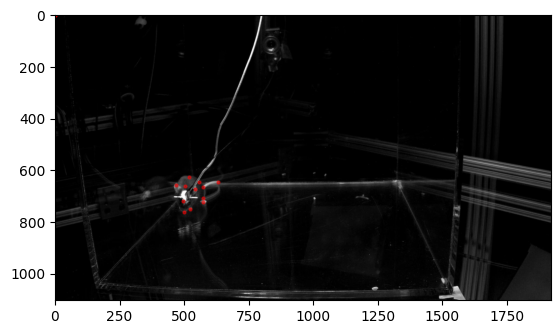

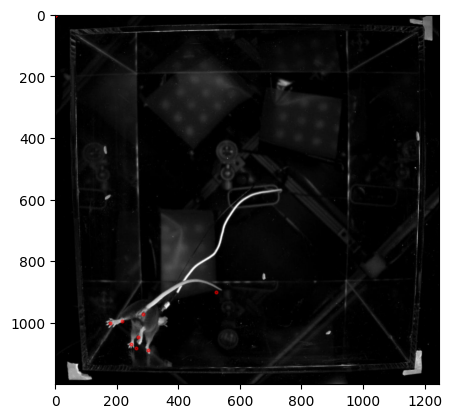

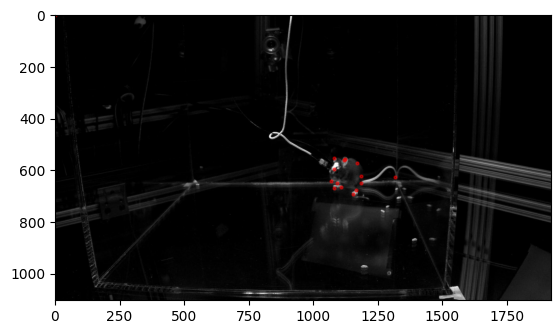

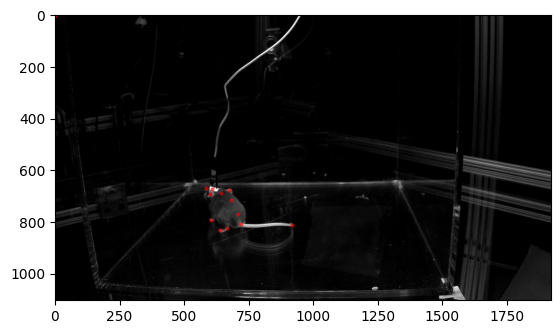

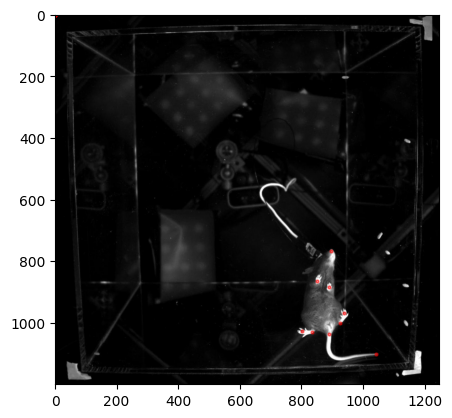

In [19]:
# Check a few random images
for i in np.random.choice(len(dataset_dict["images"]), 5):
    img = plt.imread(dataset_dict["images"][i]["file_path"])
    plt.figure()
    plt.imshow(img)
    anno_id = np.where(np.array([dataset_dict["annotations"][_]["image_id"] for _ in range(len(dataset_dict["images"]))]) == i)[0][0]
    kpts_2d = np.array(dataset_dict["annotations"][anno_id]["keypoints"]).reshape(-1, 3)
    for kpt_name in labeled_kps + unlabeled_kps:
        plt.scatter(kpts_2d[kpt_dict[kpt_name], 0], kpts_2d[kpt_dict[kpt_name], 1], s=4, c="r", alpha=0.5)
    

In [14]:
len(dataset_dict["annotations"])

1464

In [15]:
ann_ids = [a['id'] for a in dataset_dict["images"]]
assert len(set(ann_ids)) == len(ann_ids)  # if this is false, mmpose will complain

In [20]:
# # Split the dataset dict into train and validation data
# import copy
# validation_fraction = 0.1

# train_dict = copy.deepcopy(dataset_dict)
# val_dict = copy.deepcopy(dataset_dict)

# all_img_ids = np.array([img["id"] for img in dataset_dict["images"]])
# np.random.shuffle(all_img_ids)
# val_img_ids = all_img_ids[:int(len(all_img_ids) * validation_fraction)]
# train_img_ids = all_img_ids[int(len(all_img_ids) * validation_fraction):]

# train_dict["images"] = [img for img in dataset_dict["images"] if img["id"] in train_img_ids]
# train_dict["annotations"] = [anno for anno in dataset_dict["annotations"] if anno["image_id"] in train_img_ids]

# val_dict["images"] = [img for img in dataset_dict["images"] if img["id"] in val_img_ids]
# val_dict["annotations"] = [anno for anno in dataset_dict["annotations"] if anno["image_id"] in val_img_ids]

val_json = output_dir / "annotations" / "instances_val.json"
train_json = output_dir / "annotations" / "instances_train.json"

# # save the yaml files
# with open(val_json, "w") as file:
#     json.dump(val_dict, file, cls=Int32Encoder)

# with open(train_json, "w") as file:
#     json.dump(train_dict, file, cls=Int32Encoder)

In [21]:
# check its openable
with open(val_json, "r") as f:
    val_dict = json.load(f)

with open(train_json, "r") as f:
    train_dict = json.load(f)

In [22]:
len(val_dict["images"]), len(train_dict["images"])

(146, 1318)

In [23]:
# symlink the images into the COCO format folder
# symlink the image files into train/val folders for mmpose
train_img_dir = Path(output_dir) / "train"
val_img_dir = Path(output_dir) / "val"
train_img_dir.mkdir(parents=True, exist_ok=True)
val_img_dir.mkdir(parents=True, exist_ok=True)

for img in train_dict["images"]:
    img_path = Path(img["file_path"])
    (train_img_dir / img_path.name).symlink_to(img_path)

for img in val_dict["images"]:
    img_path = Path(img["file_path"])
    (val_img_dir / img_path.name).symlink_to(img_path)

### combine with other dataset

In [25]:
# combine these with the original dataset
combined_loc = "/n/groups/datta/6cam_keypoint_networks/training_data/combined_sets/JP_scale_and_forepaws/annotations"
og_train = "/n/groups/datta/6cam_keypoint_networks/training_data/JP_CW_scale_annos/COCO_format/annotations/instances_train.json"
og_val = "/n/groups/datta/6cam_keypoint_networks/training_data/JP_CW_scale_annos/COCO_format/annotations/instances_val.json"
with open(og_train, "r") as f:
    og_train_dict = json.load(f)
with open(og_val, "r") as f:
    og_val_dict = json.load(f)

# combine the dicts
train_dict["images"] += og_train_dict["images"]
train_dict["annotations"] += og_train_dict["annotations"]
val_dict["images"] += og_val_dict["images"]
val_dict["annotations"] += og_val_dict["annotations"]


In [26]:
len(train_dict["annotations"])

16713

In [27]:
# save the yaml files
combined_val_json = Path(combined_loc) / "instances_val.json"
combined_train_json = Path(combined_loc) / "instances_train.json"
with open(combined_val_json, "w") as file:
    json.dump(val_dict, file, cls=Int32Encoder)

with open(combined_train_json, "w") as file:
    json.dump(train_dict, file, cls=Int32Encoder)

In [36]:
# symlink the image files into train/val folders for mmpose
train_img_dir = Path(combined_loc) / "../train"
val_img_dir = Path(combined_loc) / "../val"
train_img_dir.mkdir(parents=True, exist_ok=True)
val_img_dir.mkdir(parents=True, exist_ok=True)

for img in train_dict["images"]:
    img_path = Path(img["file_path"])
    (train_img_dir / img_path.name).symlink_to(img_path)

for img in val_dict["images"]:
    img_path = Path(img["file_path"])
    (val_img_dir / img_path.name).symlink_to(img_path)